In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, mean_squared_error,
                             classification_report, confusion_matrix,
                             roc_curve, auc)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:
df = pd.read_csv(r"C:\Users\Spandan\Downloads\social_media_performance.csv")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:", df.isnull().sum().sum())
print("\nColumn types:")
print(df.dtypes)


Shape: (10000, 15)

First 5 rows:
   post_id  platform content_type       topic language region  \
0        1  LinkedIn      article  Technology       UR     BR   
1        2  LinkedIn         poll      Health       FR     JP   
2        3  LinkedIn      article      Travel       HI     FR   
3        4  LinkedIn        image      Sports       DE     DE   
4        5  LinkedIn         poll    Business       DE     US   

         post_datetime                                           hashtags  \
0  2025-04-25 09:47:00  #AI #Innovation #TechTrends #Programming #Codi...   
1  2025-10-29 09:44:00  #Fitness #Nutrition #Wellness #Health #MentalH...   
2  2025-02-10 14:12:00  #Travel #Journey #Adventure #Tourism #ExploreM...   
3  2025-04-18 22:41:00                         #Cricket #Workout #Fitness   
4  2025-04-28 10:17:00             #Entrepreneur #Leadership #StartupLife   

   sentiment_score  views  likes  comments  shares  engagement_rate  is_viral  
0             0.76  37781   1202

In [3]:
# Drop irrelevant columns
df.drop(columns=['post_id', 'post_datetime', 'hashtags',
                 'likes', 'comments', 'shares'], inplace=True)

# Encode categorical columns
le = LabelEncoder()
for col in ['platform', 'content_type', 'topic', 'language', 'region']:
    df[col] = le.fit_transform(df[col])

# Features & Target
X = df.drop(columns=['is_viral'])
y = df['is_viral']

print("Features used:", X.columns.tolist())
print("\nClass distribution:")
print(y.value_counts())
print(f"\nViral rate: {y.mean()*100:.1f}%")


Features used: ['platform', 'content_type', 'topic', 'language', 'region', 'sentiment_score', 'views', 'engagement_rate']

Class distribution:
is_viral
1    5457
0    4543
Name: count, dtype: int64

Viral rate: 54.6%


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (important for SVM)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")


Training samples : 8000
Testing  samples : 2000


In [5]:
svm_linear = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
svm_linear.fit(X_train_sc, y_train)

y_pred_linear  = svm_linear.predict(X_test_sc)
y_proba_linear = svm_linear.predict_proba(X_test_sc)[:, 1]

print("=" * 45)
print("        SVM – LINEAR KERNEL RESULTS")
print("=" * 45)
print(f"Accuracy : {accuracy_score(y_test, y_pred_linear):.4f}")
print(f"MSE      : {mean_squared_error(y_test, y_pred_linear):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear, target_names=['Not Viral', 'Viral']))


        SVM – LINEAR KERNEL RESULTS
Accuracy : 0.9115
MSE      : 0.0885

Classification Report:
              precision    recall  f1-score   support

   Not Viral       0.91      0.90      0.90       909
       Viral       0.92      0.92      0.92      1091

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



In [6]:
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_rbf.fit(X_train_sc, y_train)

y_pred_rbf  = svm_rbf.predict(X_test_sc)
y_proba_rbf = svm_rbf.predict_proba(X_test_sc)[:, 1]

print("=" * 45)
print("         SVM – RBF KERNEL RESULTS")
print("=" * 45)
print(f"Accuracy : {accuracy_score(y_test, y_pred_rbf):.4f}")
print(f"MSE      : {mean_squared_error(y_test, y_pred_rbf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf, target_names=['Not Viral', 'Viral']))


         SVM – RBF KERNEL RESULTS
Accuracy : 0.9495
MSE      : 0.0505

Classification Report:
              precision    recall  f1-score   support

   Not Viral       0.94      0.94      0.94       909
       Viral       0.95      0.95      0.95      1091

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



In [7]:
svm_poly = SVC(kernel='poly', degree=3, C=1.0, coef0=1,
               probability=True, random_state=42)
svm_poly.fit(X_train_sc, y_train)

y_pred_poly  = svm_poly.predict(X_test_sc)
y_proba_poly = svm_poly.predict_proba(X_test_sc)[:, 1]

print("=" * 45)
print("   SVM – POLYNOMIAL KERNEL (deg=3) RESULTS")
print("=" * 45)
print(f"Accuracy : {accuracy_score(y_test, y_pred_poly):.4f}")
print(f"MSE      : {mean_squared_error(y_test, y_pred_poly):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_poly, target_names=['Not Viral', 'Viral']))


   SVM – POLYNOMIAL KERNEL (deg=3) RESULTS
Accuracy : 0.9655
MSE      : 0.0345

Classification Report:
              precision    recall  f1-score   support

   Not Viral       0.96      0.96      0.96       909
       Viral       0.97      0.97      0.97      1091

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [8]:
dt = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
dt.fit(X_train, y_train)   # Decision Tree does NOT need scaled data

y_pred_dt  = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print("=" * 45)
print("       DECISION TREE RESULTS")
print("=" * 45)
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"MSE      : {mean_squared_error(y_test, y_pred_dt):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Not Viral', 'Viral']))


       DECISION TREE RESULTS
Accuracy : 0.9890
MSE      : 0.0110

Classification Report:
              precision    recall  f1-score   support

   Not Viral       1.00      0.98      0.99       909
       Viral       0.98      1.00      0.99      1091

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [9]:
models = ['SVM (Linear)', 'SVM (RBF)', 'SVM (Poly)', 'Decision Tree']
preds  = [y_pred_linear, y_pred_rbf, y_pred_poly, y_pred_dt]
probas = [y_proba_linear, y_proba_rbf, y_proba_poly, y_proba_dt]

comparison = pd.DataFrame({
    'Model'   : models,
    'Accuracy': [round(accuracy_score(y_test, p), 4) for p in preds],
    'MSE'     : [round(mean_squared_error(y_test, p), 4) for p in preds],
    'AUC-ROC' : [round(auc(*roc_curve(y_test, pr)[:2]), 4) for pr in probas]
})

print(comparison.to_string(index=False))


        Model  Accuracy    MSE  AUC-ROC
 SVM (Linear)    0.9115 0.0885   0.9818
    SVM (RBF)    0.9495 0.0505   0.9926
   SVM (Poly)    0.9655 0.0345   0.9957
Decision Tree    0.9890 0.0110   0.9983


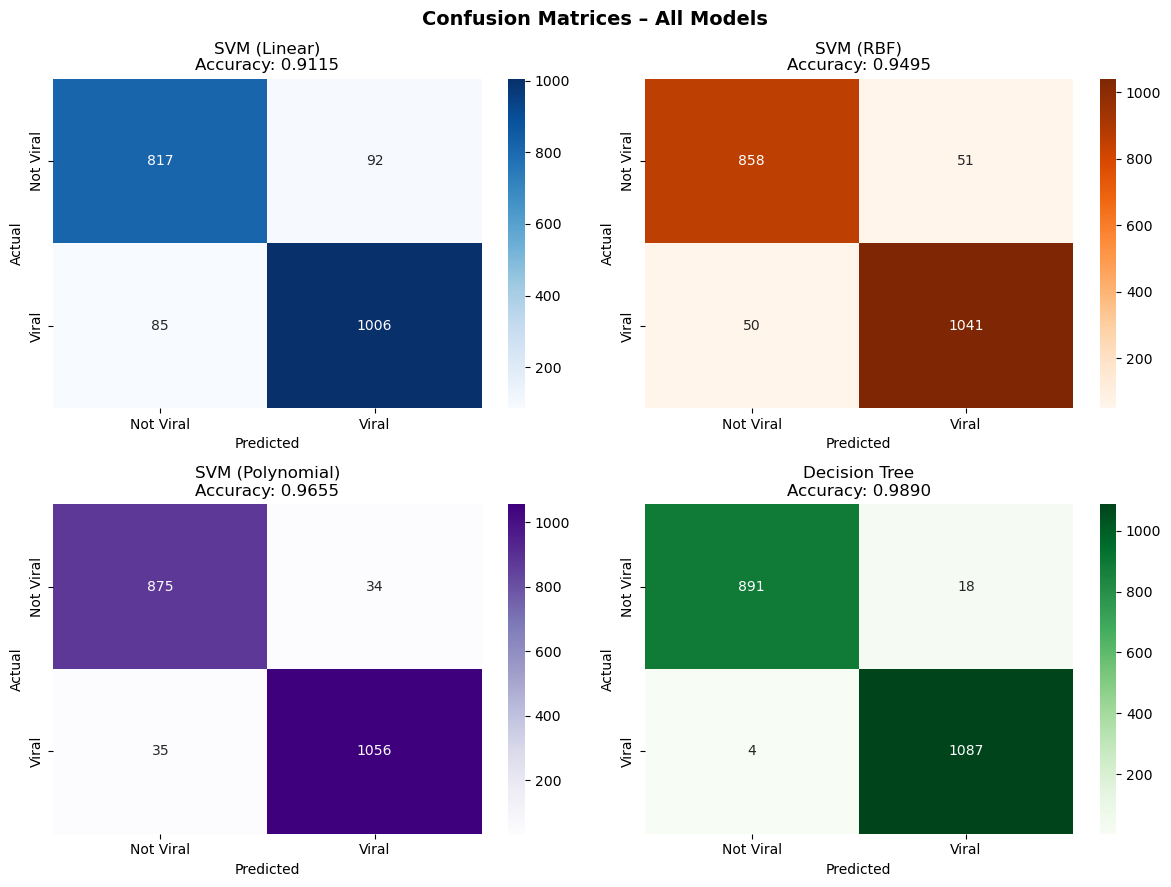

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

model_names = ['SVM (Linear)', 'SVM (RBF)', 'SVM (Polynomial)', 'Decision Tree']
all_preds   = [y_pred_linear, y_pred_rbf, y_pred_poly, y_pred_dt]
cmaps       = ['Blues', 'Oranges', 'Purples', 'Greens']

for i, (name, pred, cmap) in enumerate(zip(model_names, all_preds, cmaps)):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=['Not Viral', 'Viral'],
                yticklabels=['Not Viral', 'Viral'])
    axes[i].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred):.4f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices – All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


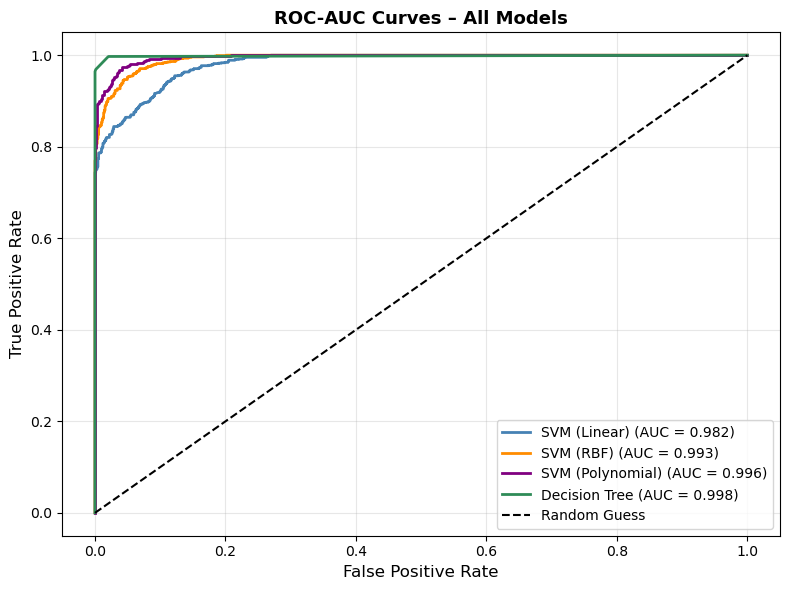

In [11]:
colors = ['steelblue', 'darkorange', 'purple', 'seagreen']

plt.figure(figsize=(8, 6))

for name, proba, color in zip(model_names, probas, colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', lw=1.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curves – All Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


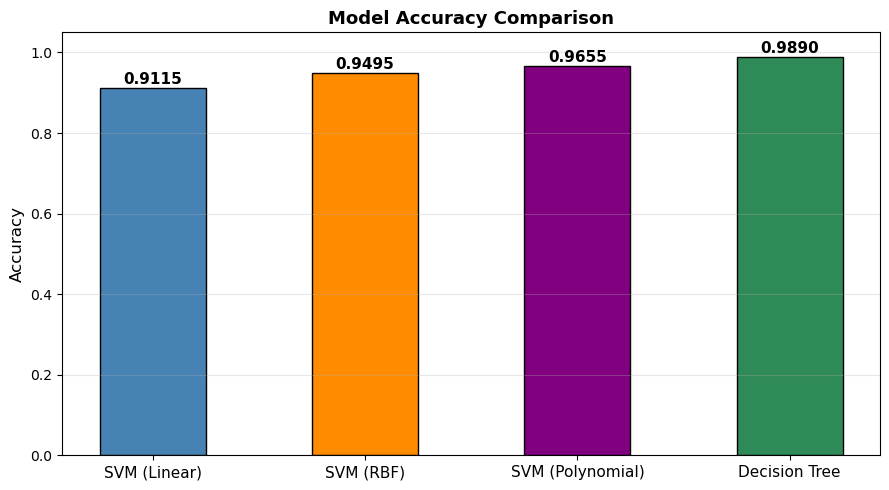

In [12]:
accuracies = [accuracy_score(y_test, p) for p in all_preds]
colors_bar = ['steelblue', 'darkorange', 'purple', 'seagreen']

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, accuracies, color=colors_bar, edgecolor='black', width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, 1.05)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
plt.xticks(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


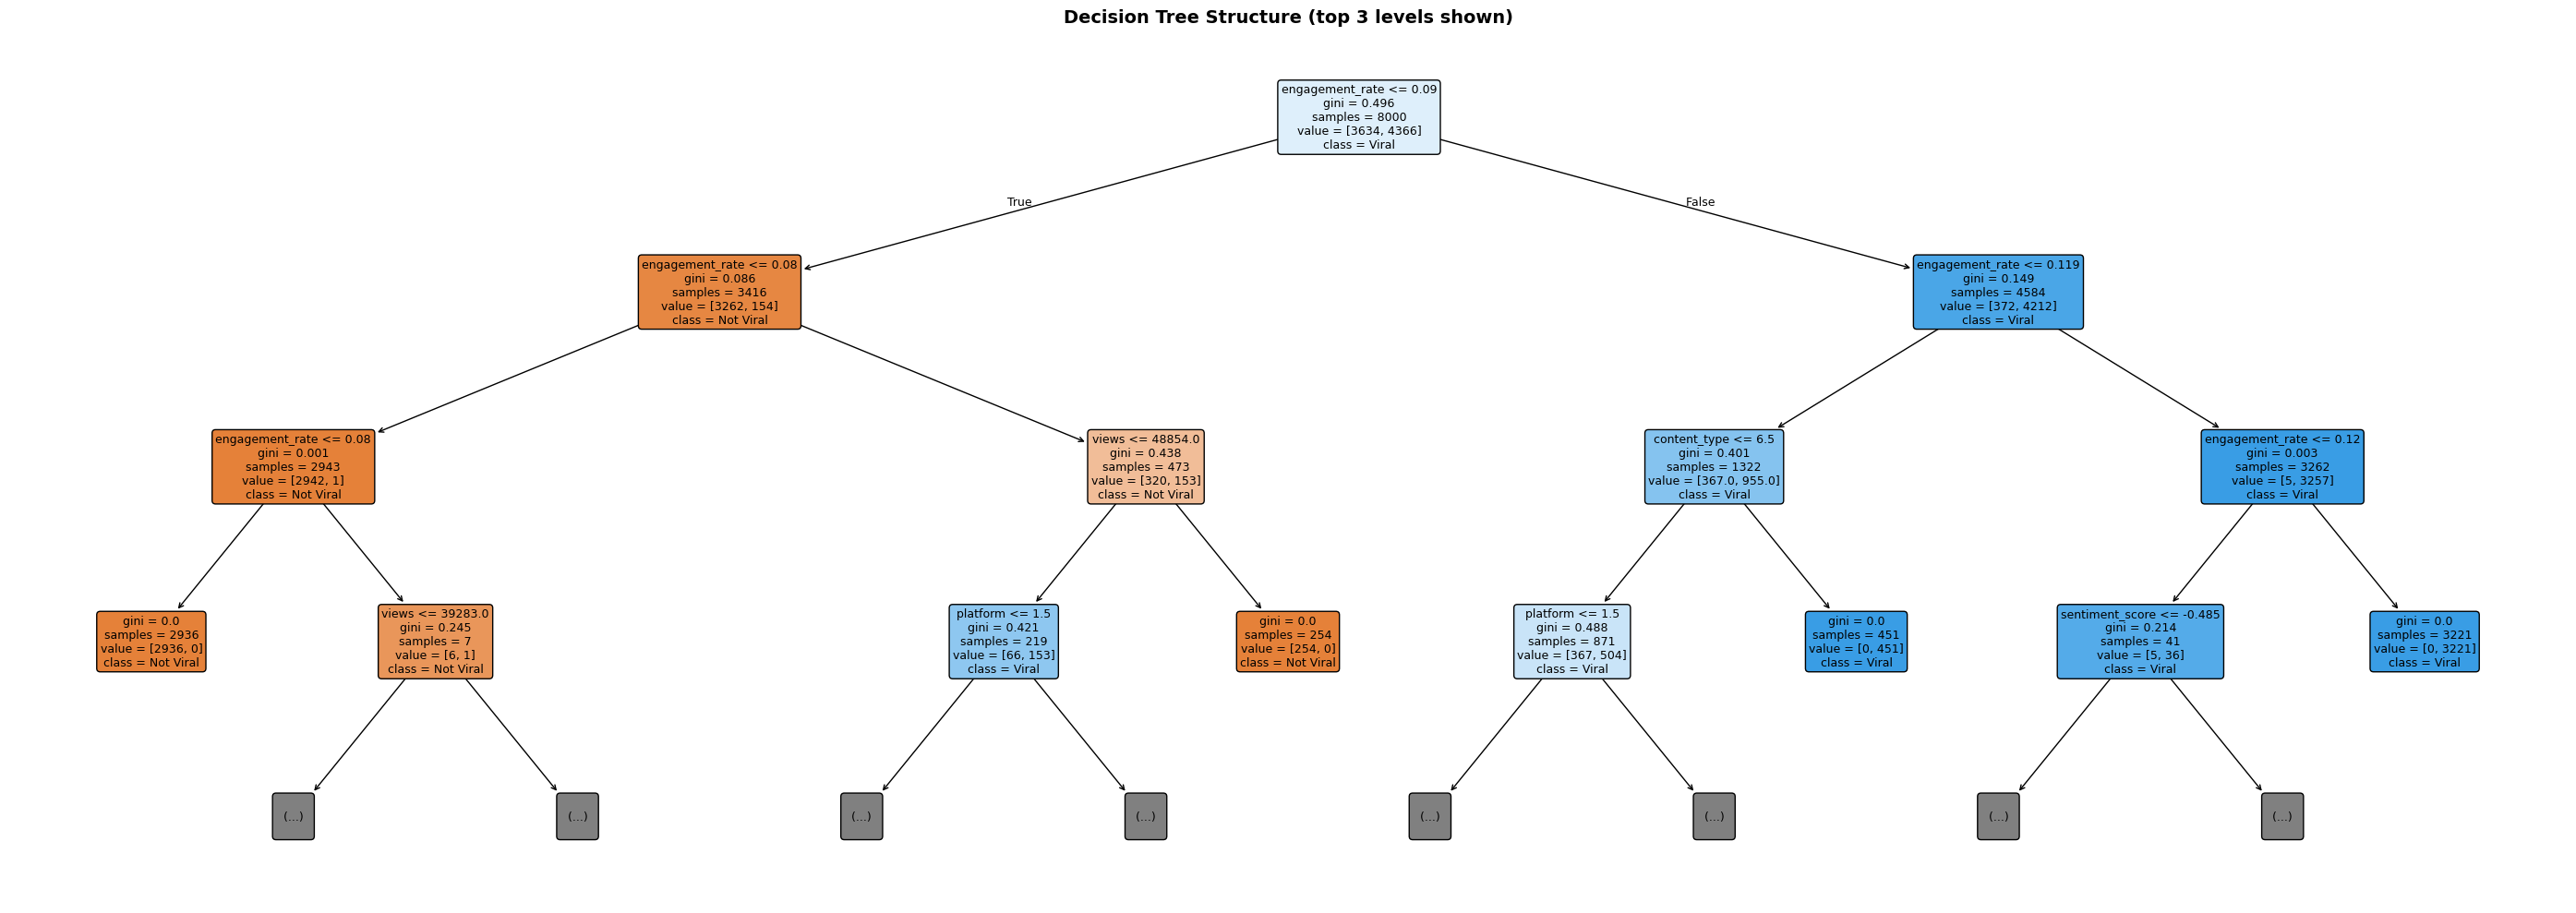

In [13]:
plt.figure(figsize=(28, 10))
plot_tree(dt,
          feature_names=X.columns.tolist(),
          class_names=['Not Viral', 'Viral'],
          filled=True,
          rounded=True,
          fontsize=9,
          max_depth=3)
plt.title('Decision Tree Structure (top 3 levels shown)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_sc)
X_test_2d  = pca.transform(X_test_sc)

kernels  = ['linear', 'rbf', 'poly']
k_labels = ['Linear', 'RBF', 'Polynomial (deg=3)']
k_colors = [['#AED6F1', '#A9DFBF'], ['#FAD7A0', '#A9DFBF'], ['#D2B4DE', '#A9DFBF']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kernel, label, cols in zip(axes, kernels, k_labels, k_colors):
    svm_2d = SVC(kernel=kernel, C=1.0, probability=True, random_state=42)
    svm_2d.fit(X_train_2d, y_train)

    x_min, x_max = X_train_2d[:, 0].min()-1, X_train_2d[:, 0].max()+1
    y_min, y_max = X_train_2d[:, 1].min()-1, X_train_2d[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    idx = np.random.choice(len(X_train_2d), size=400, replace=False)
    scatter_colors = np.where(y_train.values[idx] == 1, 'seagreen', 'steelblue')
    ax.scatter(X_train_2d[idx, 0], X_train_2d[idx, 1],
               c=scatter_colors, edgecolors='k', linewidths=0.3, s=20, alpha=0.7)

    sv = svm_2d.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=60, facecolors='none',
               edgecolors='red', linewidths=1.2, label='Support Vectors')

    ax.set_title(f'SVM – {label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.legend(fontsize=8)

plt.suptitle('SVM Decision Boundaries (PCA 2D Projection)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='seagreen', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12)
plt.title('Decision Tree – Feature Importances', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
